In [1]:
import torch
import timm
from PIL import Image
import os
from urllib.request import urlopen
import matplotlib.pyplot as plt

c:\programming\computer-vision\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
model_name = "mobilenetv3_small_100.lamb_in1k"

try:
    model = timm.create_model(model_name, pretrained=True)
except Exception as e:
    print(f"error trying to load the modelo, trying via HF hub: {e}")
    model = timm.create_model(f"hf/hub:timm/{model_name}", pretrained=True)

model.eval()

print(f"Model {model_name} loaded sucessfully")

Model mobilenetv3_small_100.lamb_in1k loaded sucessfully


In [4]:
data_config = timm.data.resolve_model_data_config(model)
transform = timm.data.create_transform(**data_config, is_training=False)

print(f"Configured transformations:\n{data_config}")
print("---"*10)
print(transform)

Configured transformations:
{'input_size': (3, 224, 224), 'interpolation': 'bicubic', 'mean': (0.485, 0.456, 0.406), 'std': (0.229, 0.224, 0.225), 'crop_pct': 0.875, 'crop_mode': 'center'}
------------------------------
Compose(
    Resize(size=256, interpolation=bicubic, max_size=None, antialias=True)
    CenterCrop(size=(224, 224))
    MaybeToTensor()
    Normalize(mean=tensor([0.4850, 0.4560, 0.4060]), std=tensor([0.2290, 0.2240, 0.2250]))
)


In [5]:
labels_url = "https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt"

with urlopen(labels_url) as f:
    categories = [line.decode("utf-8").strip() for line in f.readlines()]

print(f"{len(categories)} loaded categories")

1000 loaded categories


In [6]:
def classify_images(image_path):
    img = Image.open(image_path).convert("RGB")
    image_tensor = transform(img).unsqueeze(0)

    with torch.no_grad():
        output = model(image_tensor)

    probabilities = torch.nn.functional.softmax(output[0], dim=0)

    top5_prob, top5_catid = torch.topk(probabilities, 5)

    return [(categories[top5_catid[i]], top5_prob[i]) for i in range(top5_prob.size(0))]

Classifying image: bird.jpg


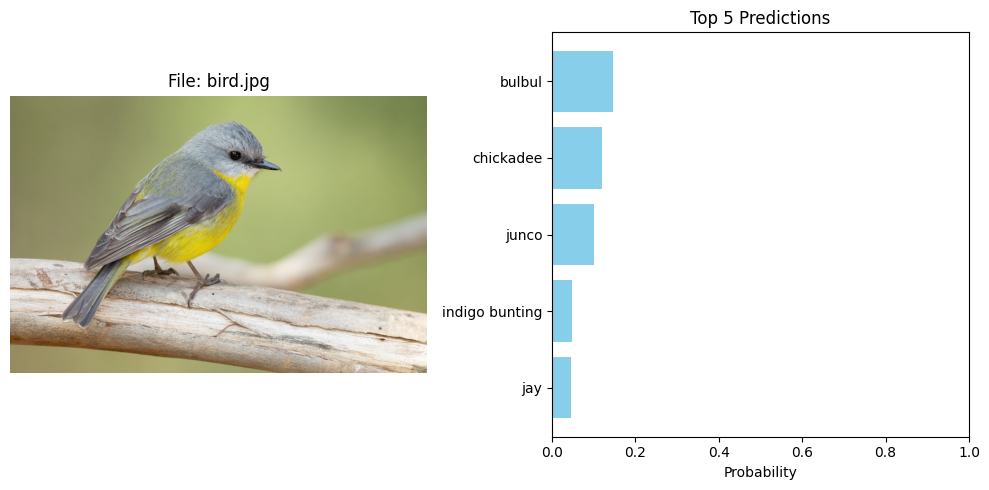

 - bulbul: 14.61%
 - chickadee: 11.93%
 - junco: 9.97%
 - indigo bunting: 4.83%
 - jay: 4.60%
Classifying image: cats_dog.png


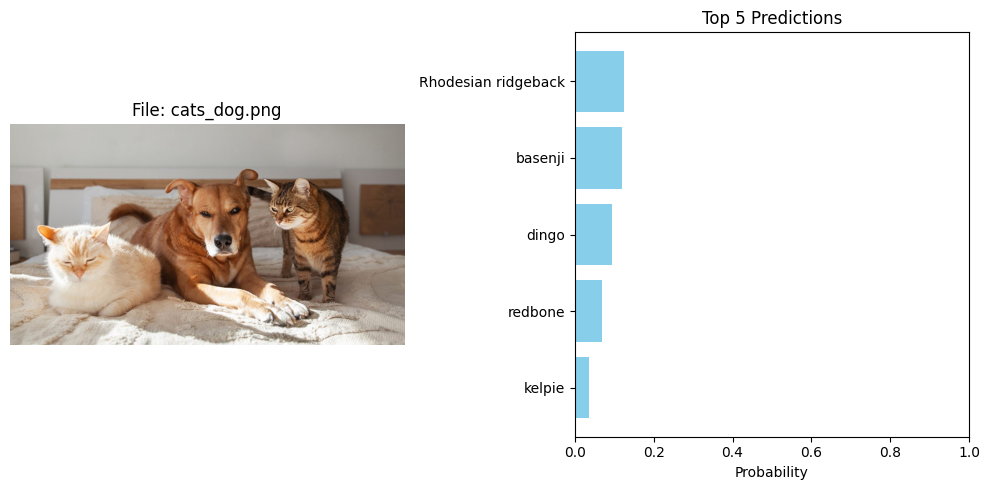

 - Rhodesian ridgeback: 12.38%
 - basenji: 12.06%
 - dingo: 9.30%
 - redbone: 6.86%
 - kelpie: 3.58%
Classifying image: kitchen.png


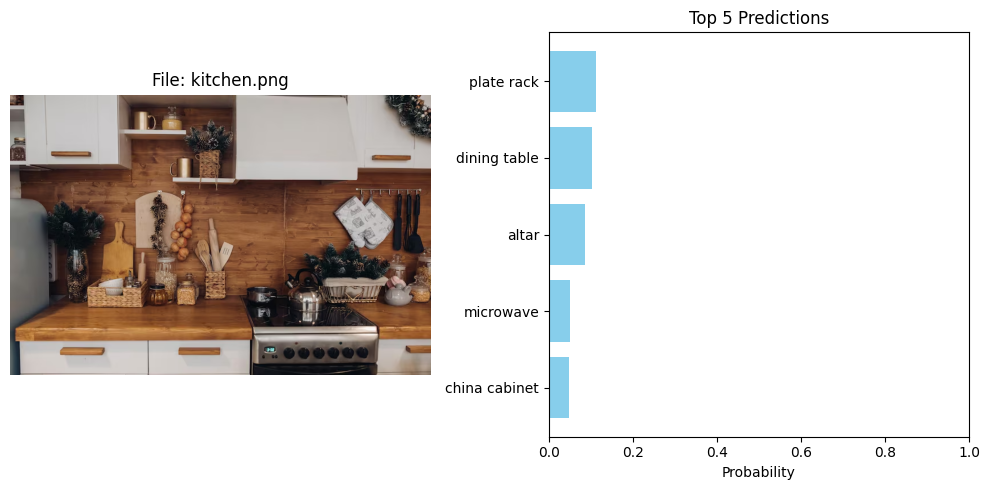

 - plate rack: 11.20%
 - dining table: 10.31%
 - altar: 8.53%
 - microwave: 5.08%
 - china cabinet: 4.85%
Classifying image: pizza.png


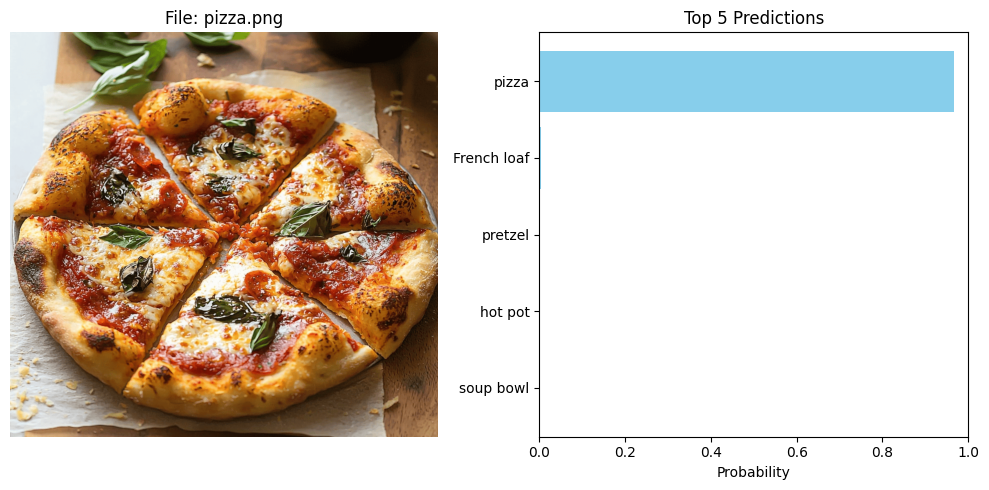

 - pizza: 96.76%
 - French loaf: 0.31%
 - pretzel: 0.20%
 - hot pot: 0.14%
 - soup bowl: 0.11%


In [8]:
def display_results():

    image_folder = 'images'
    valid_extensions = ('.jpg', '.png')
    image_files = [f for f in os.listdir(image_folder) if f.lower().endswith(valid_extensions)]

    if not image_files:
        print(f"No images found in '{image_folder}' with extensions {valid_extensions}")
        return
    
    for image_file in image_files:
        image_path = os.path.join(image_folder, image_file)
        print(f"Classifying image: {image_file}")

        results = classify_images(image_path)

        plt.figure(figsize=(10, 5))

        plt.subplot(1, 2, 1)
        plt.imshow(Image.open(image_path))
        plt.title(f"File: {image_file}")
        plt.axis('off')

        plt.subplot(1, 2, 2)
        labels = [r[0] for r in results[::-1]]
        probs = [r[1].item() for r in results[::-1]]

        plt.barh(labels, probs, color='skyblue')
        plt.xlabel('Probability')
        plt.title('Top 5 Predictions')
        plt.xlim(0, 1)

        plt.tight_layout()
        plt.show()

        for cat, prob in results:
            print(f" - {cat}: {prob*100:.2f}%")

display_results()
